### Animation, Find the Timeframe

Orbit #10369, Frame #277

Loaded 10 frames (from 0 to 9)
shape = (10, 256, 320)

UT times of displayed frames:
Frame    0  TempOH_caun0271.tif                       2025-09-21T04:53:24Z
Frame    1  TempOH_caun0272.tif                       2025-09-21T04:54:00Z
Frame    2  TempOH_caun0273.tif                       2025-09-21T04:54:37Z
Frame    3  TempOH_caun0274.tif                       2025-09-21T04:55:14Z
Frame    4  TempOH_caun0275.tif                       2025-09-21T04:55:50Z
Frame    5  TempOH_caun0276.tif                       2025-09-21T04:56:27Z
Frame    6  TempOH_caun0277.tif                       2025-09-21T04:57:04Z
Frame    7  TempOH_caun0278.tif                       2025-09-21T04:57:40Z
Frame    8  TempOH_caun0279.tif                       2025-09-21T04:58:17Z
Frame    9  TempOH_caun0280.tif                       2025-09-21T04:58:54Z

center: 19861.68, sigma: 4510.50
use range: [17606.43, 22116.92]
Saved: C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369\animation_0_9.

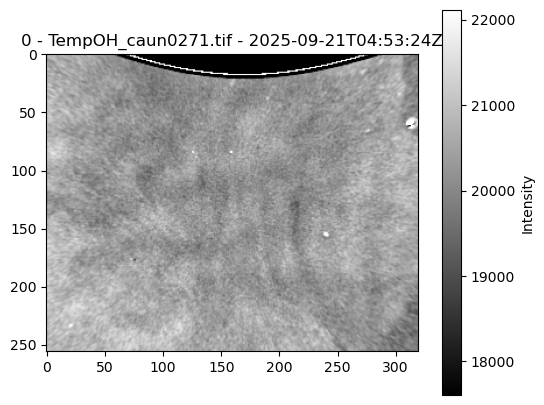

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from datetime import datetime
from pathlib import Path

# --------------------
# User settings
# --------------------
FOLDER = Path().resolve()/ "BLO Data" / "10369"

FACTOR = 0.5          # center ± FACTOR * sigma range
START_INDEX = 0     # starting frame (0-based)
N_SHOW = 10          # number of frames to show

# --------------------
# Helper: read UT time from MTM TIFF header
# --------------------
def read_ut_time_from_tiff(path):
    """
    Read UT time from the custom MTM header inside the TIFF.

    Uses the offsets from the format document:
      247-250: UT second   (ULON)
      251-254: UT minute   (ULON)
      255-258: UT hour     (ULON)
      259-262: UT day      (ULON)
      263-266: UT month    (ULON, +1 = month)
      267-270: UT year     (ULON, +1900 = year)
    Byte order is little endian ("ll" in header).
    """
    import numpy as np

    with open(path, "rb") as f:
        header = f.read(300)  # enough to cover all time fields

    def u4(offset):
        # little-endian unsigned 4-byte integer
        return np.frombuffer(header[offset:offset+4], dtype="<u4")[0]

    sec   = int(u4(247))
    minute = int(u4(251))
    hour   = int(u4(255))
    day    = int(u4(259))
    month  = int(u4(263)) + 1     # +1 = month
    year   = int(u4(267)) + 1900  # +1900 = year

    return datetime(year, month, day, hour, minute, sec)

# --------------------
# Load all TIFFs
# --------------------
files_all = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files_all:
    raise FileNotFoundError("No TIFFs found in folder.")

# Limit to desired range
files = files_all[START_INDEX: START_INDEX + N_SHOW]

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)

print(f"Loaded {len(files)} frames (from {START_INDEX} to {START_INDEX+len(files)-1})")
print(f"shape = {data.shape}")

# --------------------
# Read UT time for each displayed frame
# --------------------
times_utc = [read_ut_time_from_tiff(f) for f in files]

print("\nUT times of displayed frames:")
for i, (fname, t_utc) in enumerate(zip(files, times_utc)):
    frame_idx = START_INDEX + i
    print(f"Frame {frame_idx:4d}  {os.path.basename(fname):40s}  {t_utc.isoformat()}Z")

# --------------------
# Compute intensity range
# --------------------
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"\ncenter: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

# Include frame index, filename, and UT time in the title
title = ax.set_title(
    f"{START_INDEX} - {os.path.basename(files[0])} - {times_utc[0].isoformat()}Z"
)
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    t_utc = times_utc[i]
    title.set_text(
        f"{START_INDEX + i} - {os.path.basename(files[i])} - {t_utc.isoformat()}Z"
    )
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())

# --------------------
# Save animation as MP4
# --------------------
out_mp4 = FOLDER / f"animation_{START_INDEX}_{START_INDEX+len(files)-1}.mp4"

anim.save(
    out_mp4,
    writer="ffmpeg",
    fps=2.5,          # 400 ms per frame ≈ 2.5 fps
    dpi=150
)

print("Saved:", out_mp4)


Frame 460

## One Frame

Selected ROI labels:
  ROI_74: x=140:260, y=96:216
[Full] image shape: 256 x 320
[Full] mean: 19995.48
[Full] sigma: 4534.31
[Full] Clip range: [17728.33, 22262.64] = mean ± 0.50·sigma


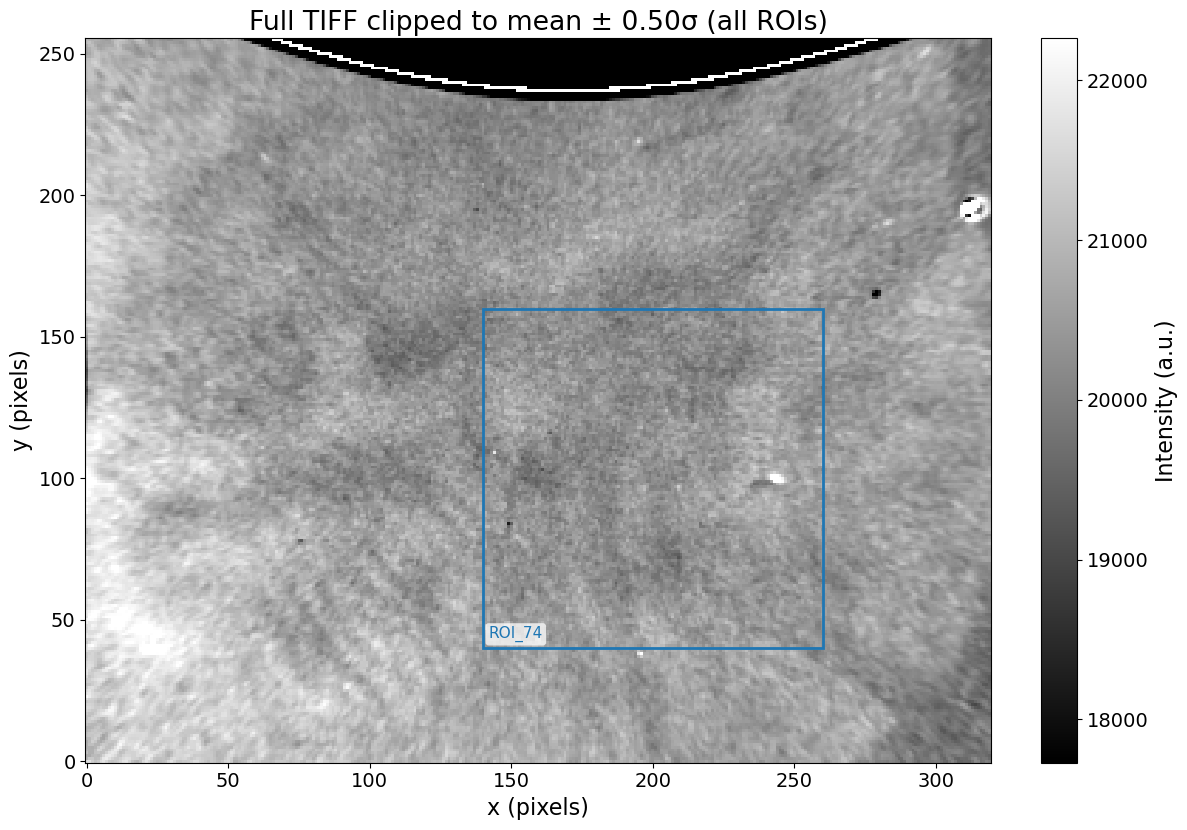


[ROI: ROI_74] shape: (120, 120)   X=slice(140, 260, None)   Y=slice(96, 216, None)
[ROI: ROI_74] Count: 14400
[ROI: ROI_74] Min/max after clip: 18259.00 / 22262.64
[ROI: ROI_74] Percentiles 5/50/95 (clipped): 19895.95 / 20364.00 / 20865.00


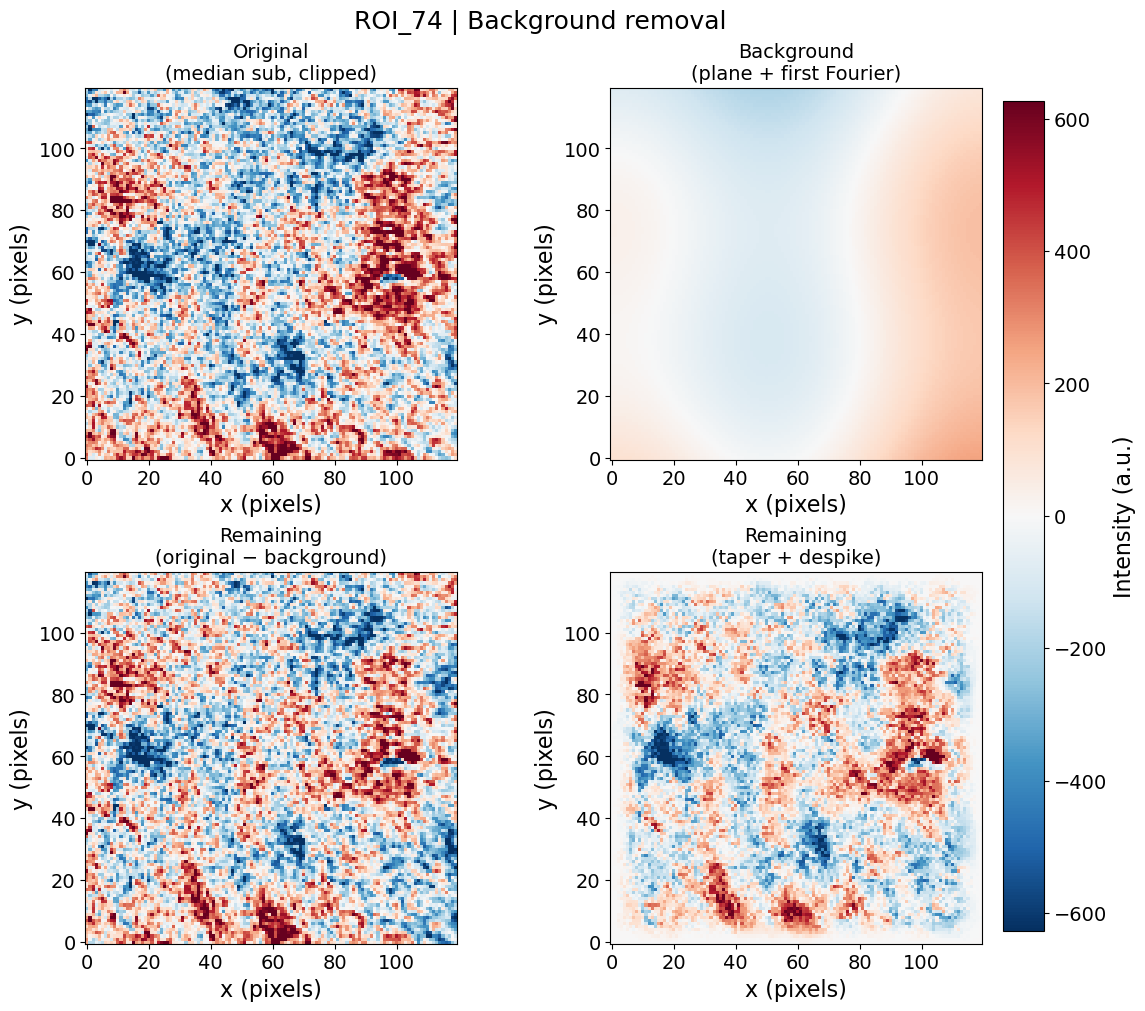

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.4861855758512155 idx= (np.int64(8), np.int64(35), np.int64(50), np.int64(81))
selected elements: 137184
------------
cluster= 1
amplitude= 0.42101470077704267 idx= (np.int64(8), np.int64(0), np.int64(50), np.int64(76))
selected elements: 49491
------------
cluster= 2
amplitude= 0.3253545955540346 idx= (np.int64(18), np.int64(17), np.int64(49), np.int64(80))
selected elements: 148150
------------
cluster= 3
amplitude= 0.30841490203742966 idx= (np.int64(0), np.int64(1), np.int64(97), np.int64(63))
selected elements: 14647
------------
cluster= 4
amplitude= 0.3005300705644641 idx= (np.int64(0), np.int64(6), np.int64(94), np.int64(58))
selected elements: 4289
------------
cluster= 5
amplitude= 0.28639553980559146 idx= (np.int64(0), np.int64(20), np.int64(75), np.int64(27))
selected elements: 6090
------------
cluster= 6
amplitude= 0.2855326306993406 idx= (np.int64(0), np.int64(18), np.int64(102), np.int64(59))
selected elements: 5618
------------
cluste

C:\Users\domin\juwavelet\juwavelet\utils.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 141.24it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


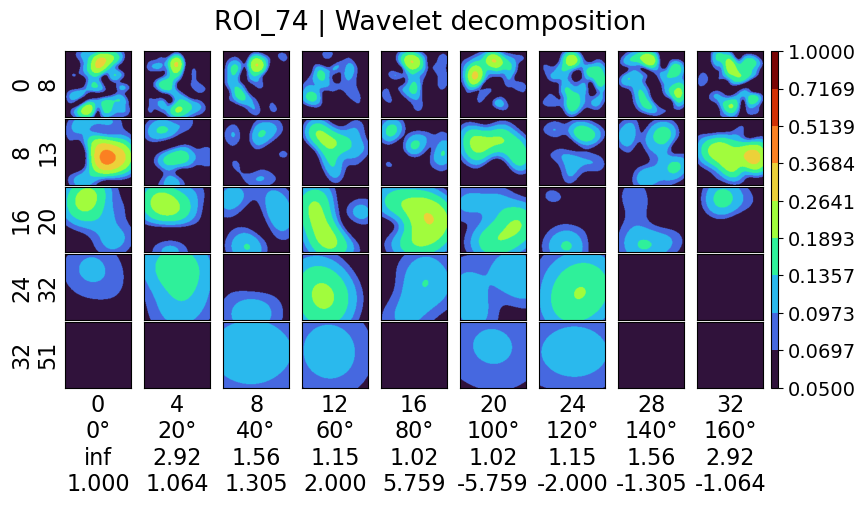

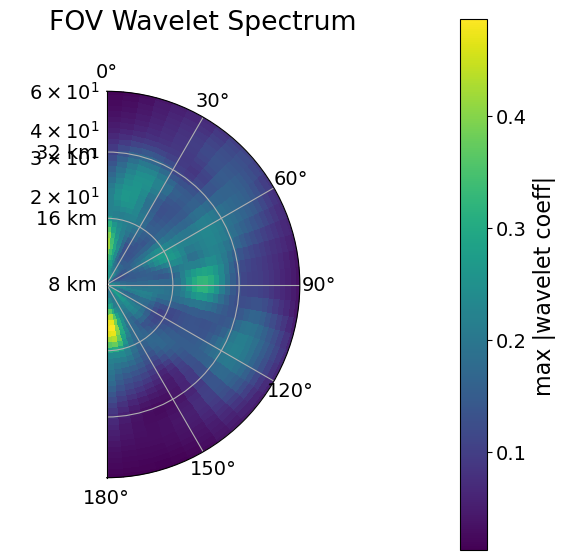

<Figure size 1388x858 with 0 Axes>

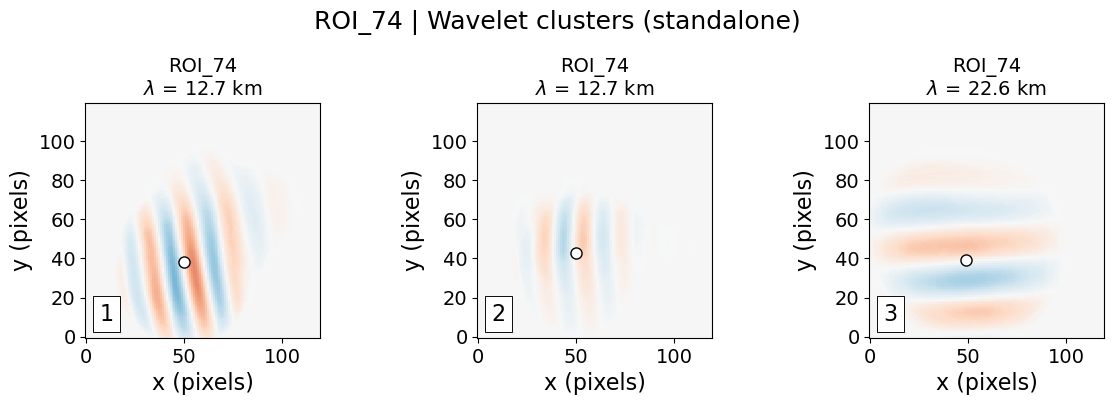

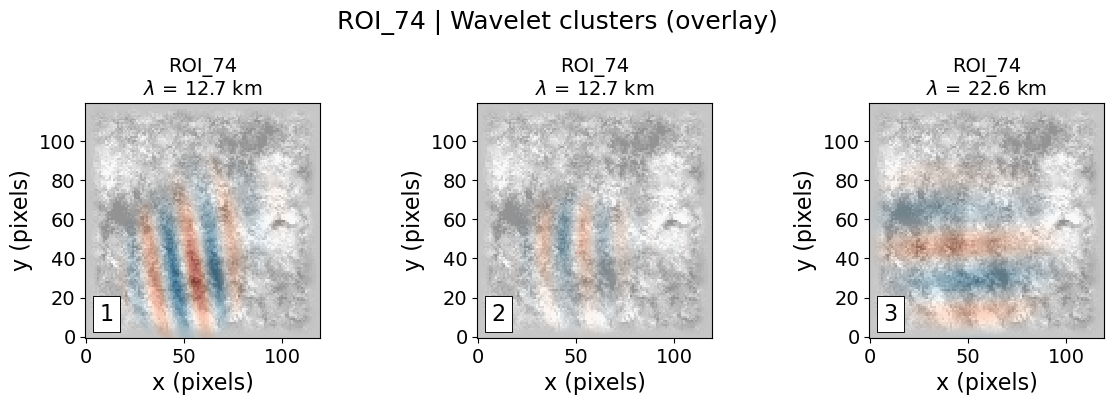

In [2]:
# Full TIFF -> MULTI-ROI -> background removal -> wavelet clusters
#
# For each ROI in ROI_LABELS, produces:
#   1) Full TIFF preview (mean ± SIGMA_FACTOR*sigma) with ALL ROI rectangles
#   2) 4-panel background figure (orig/bg/remaining/taper+despike)
#   3) Wavelet decomposition summary (utils.plot_decomposition2d)
#   4) FOV wavelet spectrum (orientation vs wavelength)
#   5) Standalone wavelet clusters (up to N_CLUSTERS_SHOW)
#   6) Overlay clusters on top of tapered remaining field (up to N_CLUSTERS_SHOW)
#
# Notes:
#   - The clip range (lo/hi) is computed ONCE from the full image and reused for all ROIs.
#   - Each ROI run is independent and prints its own summaries.
#   - ROI labels are converted automatically using:
#
#       ROI ab:
#           x = 20*a : 120 + 20*a
#           y = 16 + 20*b : 136 + 20*b
#
#     Image size: 320 x 256
#     a = 0..10, b = 0..6 (no clipping)

from __future__ import annotations
from typing import Tuple, Optional, List

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils
from pathlib import Path


# --------------------
# User settings
# --------------------
TIFF_PATH = Path().resolve() / r"BLO Data\10369\TempOH_caun0277.tif"

# ---- ROI labels to analyze ----
# label "ab" means a = first digits, b = last digit
# Example:
#   104 -> a=10, b=4
#   56  -> a=5,  b=6
ROI_LABELS = [74]

# ROI definition
IMG_NX = 320
IMG_NY = 256

ROI_WIDTH = 120
ROI_HEIGHT = 120
ROI_X_STEP = 20
ROI_Y_STEP = 20
ROI_Y0 = 16

A_MIN, A_MAX = 0, 10
B_MIN, B_MAX = 0, 6

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 8
DJ = 1 / 12
JS = 36
JT = 36
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# How many clusters to show in the summary figures
N_CLUSTERS_SHOW = 3


# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# ROI helpers
# --------------------------
def parse_roi_label(label: int | str) -> Tuple[int, int]:
    """
    Parse ROI label into (a, b).

    Convention:
      last digit  -> b
      remaining   -> a

    Examples:
      104 -> (10, 4)
      56  -> (5, 6)
      "03" -> (0, 3)
    """
    s = str(label).strip()
    if not s.isdigit():
        raise ValueError(f"ROI label must be numeric, got: {label}")

    if len(s) < 2:
        raise ValueError(f"ROI label must have at least 2 digits, got: {label}")

    a = int(s[:-1])
    b = int(s[-1])
    return a, b


def roi_label_to_slices(label: int | str) -> Tuple[str, slice, slice]:
    """
    Convert ROI label into (name, x_slice, y_slice)
    using the user's new ROI definition.
    """
    a, b = parse_roi_label(label)

    if not (A_MIN <= a <= A_MAX):
        raise ValueError(f"ROI label {label}: a={a} outside allowed range {A_MIN}..{A_MAX}")
    if not (B_MIN <= b <= B_MAX):
        raise ValueError(f"ROI label {label}: b={b} outside allowed range {B_MIN}..{B_MAX}")

    x0 = ROI_X_STEP * a
    x1 = ROI_WIDTH + ROI_X_STEP * a
    y0 = ROI_Y0 + ROI_Y_STEP * b
    y1 = ROI_Y0 + ROI_HEIGHT + ROI_Y_STEP * b

    if x0 < 0 or x1 > IMG_NX or y0 < 0 or y1 > IMG_NY:
        raise ValueError(
            f"ROI label {label} gives out-of-bounds ROI: "
            f"x={x0}:{x1}, y={y0}:{y1}, image={IMG_NX}x{IMG_NY}"
        )

    name = f"ROI_{label}"
    return name, slice(x0, x1), slice(y0, y1)


def build_roi_sets_from_labels(labels: List[int | str]) -> List[Tuple[str, slice, slice]]:
    """Build ROI_SETS automatically from ROI_LABELS."""
    roi_sets = []
    for label in labels:
        roi_sets.append(roi_label_to_slices(label))
    return roi_sets


# --------------------------
# Helpers
# --------------------------
def load_tiff(path: str | Path) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(str(path))
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """Fit a 2D plane ax + by + c to Z (least squares) and return the plane."""
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    return (coeff[0] * xx + coeff[1] * yy + coeff[2])


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Keep only the first Fourier components in x and y:
      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0
    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(Z: np.ndarray, size: int = 3, k: float = 5.0) -> np.ndarray:
    """Replace pixels that deviate too much from a local median (MAD-based)."""
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)
    mask_spike = np.abs(Z - med) > k * mad
    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """1D window: ramps from 0 at edges to 1 over `edge` pixels, 1 in interior."""
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """Apply separable 2D edge taper (Hanning-like) near boundaries."""
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)
    return Z * W


def _slice_bounds(s: Optional[slice], n: int) -> Tuple[int, int]:
    """Convert slice into [start, stop) bounds with defaults."""
    if s is None:
        return 0, n
    start = 0 if s.start is None else int(s.start)
    stop = n if s.stop is None else int(s.stop)
    return start, stop


# --------------------------
# Full-image preview with ALL ROIs
# --------------------------
def plot_full_preview_with_rois(full: np.ndarray, lo: float, hi: float, roi_sets):
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)
    y_full_flip = y_full[::-1]

    disp_prev = np.clip(full.astype(float), lo, hi)

    fig_prev, ax_prev = plt.subplots()
    im_prev = ax_prev.pcolormesh(
        x_full, y_full_flip, disp_prev,
        shading="auto", cmap="gray", vmin=lo, vmax=hi
    )
    cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
    cb_prev.set_label("Intensity (a.u.)")

    ax_prev.set_xlabel("x (pixels)")
    ax_prev.set_ylabel("y (pixels)")
    ax_prev.set_aspect("equal", adjustable="box")
    ax_prev.set_title(f"Full TIFF clipped to mean ± {SIGMA_FACTOR:.2f}σ (all ROIs)")

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (name, xsl, ysl) in enumerate(roi_sets):
        x0, x1 = _slice_bounds(xsl, nx_full)
        y0, y1 = _slice_bounds(ysl, ny_full)

        # Map ROI y-range to flipped-y display coords
        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp), x1 - x0, y1_disp - y0_disp,
            linewidth=2, edgecolor=colors[i % len(colors)], facecolor="none"
        )
        ax_prev.add_patch(rect)

        ax_prev.text(
            x0 + 2, y0_disp + 2, name,
            color=colors[i % len(colors)], fontsize=11,
            va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)
        )

    plt.tight_layout()
    plt.show(fig_prev)


# --------------------------
# Per-ROI pipeline
# --------------------------
def run_one_roi(full: np.ndarray, lo: float, hi: float, roi_name: str,
                x_slice: Optional[slice], y_slice: Optional[slice]) -> None:

    ny_full, nx_full = full.shape
    ysl = y_slice if y_slice is not None else slice(None, None)
    xsl = x_slice if x_slice is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]  # flip y for display

    print("\n" + "=" * 80)
    print(f"[ROI: {roi_name}] shape: {raw.shape}   X={x_slice}   Y={y_slice}")

    # Clip ROI values to [lo, hi]
    proc0 = np.clip(raw, lo, hi)

    vals_roi = proc0.ravel()
    if vals_roi.size > 0:
        print(f"[ROI: {roi_name}] Count: {vals_roi.size}")
        print(f"[ROI: {roi_name}] Min/max after clip: {np.nanmin(vals_roi):.2f} / {np.nanmax(vals_roi):.2f}")
        p5r, p50r, p95r = np.nanpercentile(vals_roi, [5, 50, 95])
        print(f"[ROI: {roi_name}] Percentiles 5/50/95 (clipped): {p5r:.2f} / {p50r:.2f} / {p95r:.2f}")
    else:
        print(f"[ROI: {roi_name}] Warning: no pixels?")

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike after taper
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med0 = np.nanmedian(proc0)
    orig_c = proc0 - med0
    bg_c = background - med0
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel(), rem_tapered_c.ravel()])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 4-panel background figure
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    fig_bg.suptitle(f"{roi_name} | Background removal", fontsize=18)

    imgs_bg = [
        (orig_c, "Original\n(median sub, clipped)"),
        (bg_c, "Background\n(plane + first Fourier)"),
        (rem_c, "Remaining\n(original − background)"),
        (rem_tapered_c, "Remaining\n(taper + despike)"),
    ]

    im_bg = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d, y1d, Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title, fontsize=14, pad=6)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal", adjustable="box")

    cbar_bg = fig_bg.colorbar(
        im_bg,
        ax=axs_bg,
        orientation="vertical",
        fraction=0.04,
        pad=0.02,
    )
    cbar_bg.set_label("Intensity (a.u.)")

    plt.show(fig_bg)

    # Preprocess for CWT only (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # Overview CWT plot
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
    )
    fig_cwt, _ = utils.plot_decomposition2d(
        cwt, redux_s=8, redux_t=4, cmap=cmap_cwt, norm=norm_cwt
    )
    fig_cwt.suptitle(f"{roi_name} | Wavelet decomposition", y=1.02)
    plt.show(fig_cwt)

    # FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")
    plt.gcf().suptitle(f"{roi_name} | FOV wavelet spectrum", y=1.02)
    plt.show()

    # Background image for overlays: tapered remaining (spikes removed), centered
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    number_box = {"boxstyle": "square", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}

    # -------------------------------------------------
    # Figure 1: standalone clusters
    # -------------------------------------------------
    fig1, axs1 = plt.subplots(1, N_CLUSTERS_SHOW, figsize=(4 * N_CLUSTERS_SHOW, 4))
    axes1_flat = np.atleast_1d(axs1).ravel()

    fig1.suptitle(f"{roi_name} | Wavelet clusters (standalone)", fontsize=18)

    opts_img_cluster = {
        "cmap": "RdBu_r",
        "vmin": -0.8,
        "vmax": 0.8,
        "rasterized": True,
    }

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes1_flat:
            ax.set_title("No clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(N_CLUSTERS_SHOW, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat[:n_show], biggest):
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2

            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                rf"{roi_name}" + "\n" + rf"$\lambda$ = {_fmt(lam)} km",
                fontsize=14,
            )

            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img_cluster)
            ax.set_aspect("equal", adjustable="box")

            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(),
                decomposition[0, 0].shape,
            )
            ax.plot(x1d[max_idx[0]], y1d[max_idx[1]], "o",
                    color="w", mec="k", ms=8)

        for ax in axes1_flat[n_show:]:
            ax.axis("off")

    for i, ax in enumerate(axes1_flat, start=1):
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.text(
            0.12, 0.15, str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # -------------------------------------------------
    # Figure 2: overlays
    # -------------------------------------------------
    fig2, axs2 = plt.subplots(1, N_CLUSTERS_SHOW, figsize=(4 * N_CLUSTERS_SHOW, 4))
    axes2_flat = np.atleast_1d(axs2).ravel()

    fig2.suptitle(f"{roi_name} | Wavelet clusters (overlay)", fontsize=18)

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("No clusters found")
            ax.axis("off")
    else:
        cl_vmin, cl_vmax = -0.6, 0.6
        order = np.argsort(amps)[::-1]
        n_show = min(N_CLUSTERS_SHOW, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes2_flat[:n_show], biggest):
            ax.pcolormesh(
                x1d, y1d, bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2

            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d, y1d, rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(
                rf"{roi_name}" + "\n" + rf"$\lambda$ = {_fmt(lam)} km",
                fontsize=14,
            )
            ax.set_aspect("equal", adjustable="box")

        for ax in axes2_flat[n_show:]:
            ax.axis("off")

    for i, ax in enumerate(axes2_flat, start=1):
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.text(
            0.12, 0.15, str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


# --------------------------
# Run (multi-ROI)
# --------------------------
def run_pipeline_multi_roi():
    # Build ROI sets automatically from labels
    roi_sets = build_roi_sets_from_labels(ROI_LABELS)

    print("Selected ROI labels:")
    for name, xsl, ysl in roi_sets:
        print(f"  {name}: x={xsl.start}:{xsl.stop}, y={ysl.start}:{ysl.stop}")

    # Load full TIFF once
    full = load_tiff(TIFF_PATH)

    # Optional sanity check against expected image size
    ny_full, nx_full = full.shape
    print(f"[Full] image shape: {ny_full} x {nx_full}")
    if nx_full != IMG_NX or ny_full != IMG_NY:
        print(f"[Warning] Expected image size {IMG_NY} x {IMG_NX}, got {ny_full} x {nx_full}")

    # Compute mean/std once on full image for consistent clip
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean: {center:.2f}")
    print(f"[Full] sigma: {sigma:.2f}")
    print(f"[Full] Clip range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # Full-image preview with ALL ROIs drawn
    plot_full_preview_with_rois(full, lo, hi, roi_sets)

    # Run each ROI
    for roi_name, xsl, ysl in roi_sets:
        run_one_roi(full, lo, hi, roi_name, xsl, ysl)


if __name__ == "__main__":
    run_pipeline_multi_roi()

## Save Crest Relative Amplitude Evolution, Weighted mean

Using ROIs:
  ROI_74: x=140:260, y=96:216
Found 10 TIFF files in C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369
Overlay base directory: C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369\overlays_crests_phase

=== ROI: ROI_74 | X=slice(140, 260, None) | Y=slice(96, 216, None) ===


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


[ROI_74] Saved CSV: C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369\overlays_crests_phase\ROI_74\crest_relative_amplitude_evolution.csv


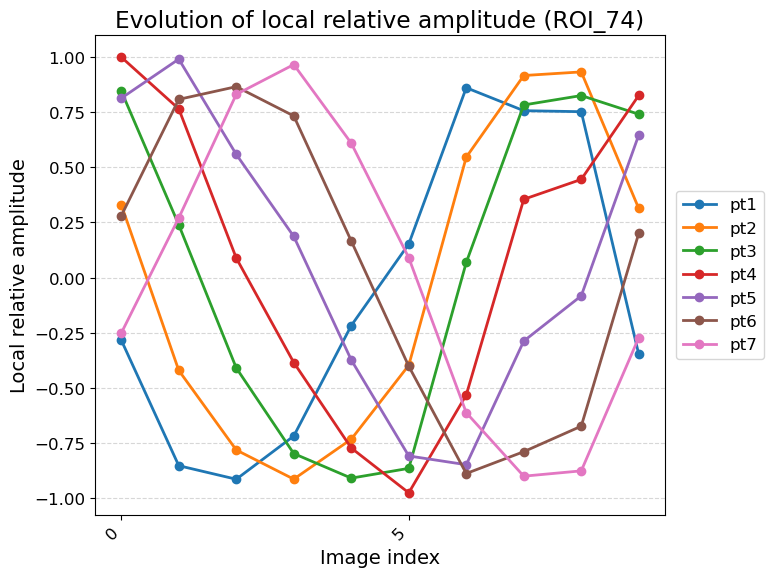

In [4]:
# %%
# Full (sliced) TIFF -> ROI -> background removal -> wavelet clusters
# (batch version, with crest marker + ridge line + relative-amplitude panel)
#
# MULTI-ROI VERSION:
#   - Define ROI labels in ROI_LABELS
#   - Builds ROI slices automatically from the ROI definition
#   - Runs the same pipeline for each ROI
#   - Saves each ROI run into its own subfolder so nothing overwrites
#
# Updates:
#   - Use FOLDER = Path().resolve() / "BLO Data" / "01787"
#   - Use ROIs from the previous cell via ROI_LABELS
#   - Keep the original processing pipeline unchanged
#   - When saving the CSV, do NOT save NPY
#   - Save wavelength and angle for each image/frame
#   - Wavelength is now amplitude-weighted mean wavelength inside the selected cluster
#   - Angle is now amplitude-weighted circular mean angle inside the selected cluster
#   - Wavelength error is amplitude-weighted standard deviation inside the selected cluster
#   - Angle error is amplitude-weighted circular standard deviation inside the selected cluster
#
# CSV columns:
#   image_index
#   wavelength_km
#   wavelength_error_km
#   angle_deg
#   angle_error_deg
#   pt1, pt2, ..., ptN

from __future__ import annotations
from typing import Tuple, Optional, List
from pathlib import Path
import csv

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter, maximum_filter, minimum_filter
from scipy import ndimage
from skimage import morphology

from juwavelet import transform, utils


def _silent_print(*args, **kwargs):
    pass


utils.print = _silent_print


# --------------------------
# User params
# --------------------------
FOLDER = Path().resolve() / "BLO Data" / "10369"

# Define this in previous cell, or uncomment here:
# ROI_LABELS = [104, 56]

IMG_NX = 320
IMG_NY = 256

ROI_WIDTH = 120
ROI_HEIGHT = 120
ROI_X_STEP = 20
ROI_Y_STEP = 20
ROI_Y0 = 16

A_MIN, A_MAX = 0, 10
B_MIN, B_MAX = 0, 6

OVERLAY_DIR: Optional[str] = None

SIGMA_FACTOR = 0.5

REMOVE_TREND = True
STANDARDIZE = True
GAUSS_BLUR_SIGMA = 0

APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10

APPLY_DESPIKE = True
DESPIKE_SIZE = 5
DESPIKE_K = 2.0

S0 = 8
DJ = 1 / 12
JS = 36
JT = 36
ASPECT = 1

DX = 0.623
DY = 0.623

CLUSTER_MIN_AMP = 0.25
CLUSTER_THR = 0.1

ENABLE_BANDPASS = True
BANDPASS_LMIN_KM = 8.0
BANDPASS_LMAX_KM = 16.0

ENABLE_ANGLE_FILTER = True
ANGLE_MIN_DEG = 160.0
ANGLE_MAX_DEG = 180.0

MAX_CLUSTERS = 1

CREST_NEIGHBORHOOD = 7
CREST_MIN_RELAMP = 0.2
CRESTS_PER_CLUSTER = 1

N_SAMPLE_POINTS = 7

SHOW_FIGS = False
SAVE_OVERLAY = True

VERBOSE = False


matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": [12, 8],
})


def log(msg: str) -> None:
    if VERBOSE:
        print(msg)


# --------------------------
# ROI helpers
# --------------------------
def parse_roi_label(label: int | str) -> Tuple[int, int]:
    s = str(label).strip()
    if not s.isdigit():
        raise ValueError(f"ROI label must be numeric, got: {label}")
    if len(s) < 2:
        raise ValueError(f"ROI label must have at least 2 digits, got: {label}")

    a = int(s[:-1])
    b = int(s[-1])
    return a, b


def roi_label_to_slices(label: int | str) -> Tuple[str, slice, slice]:
    a, b = parse_roi_label(label)

    if not (A_MIN <= a <= A_MAX):
        raise ValueError(f"ROI label {label}: a={a} outside allowed range {A_MIN}..{A_MAX}")
    if not (B_MIN <= b <= B_MAX):
        raise ValueError(f"ROI label {label}: b={b} outside allowed range {B_MIN}..{B_MAX}")

    x0 = ROI_X_STEP * a
    x1 = ROI_WIDTH + ROI_X_STEP * a
    y0 = ROI_Y0 + ROI_Y_STEP * b
    y1 = ROI_Y0 + ROI_HEIGHT + ROI_Y_STEP * b

    if x0 < 0 or x1 > IMG_NX or y0 < 0 or y1 > IMG_NY:
        raise ValueError(
            f"ROI label {label} gives out-of-bounds ROI: "
            f"x={x0}:{x1}, y={y0}:{y1}, image={IMG_NX}x{IMG_NY}"
        )

    name = f"ROI_{label}"
    return name, slice(x0, x1), slice(y0, y1)


def build_roi_sets_from_labels(labels: List[int | str]) -> List[Tuple[str, slice, slice]]:
    return [roi_label_to_slices(label) for label in labels]


# --------------------------
# Image helpers
# --------------------------
def load_tiff(path: str) -> np.ndarray:
    img = tiff.imread(path)

    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]

    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    return coeff[0] * xx + coeff[1] * yy + coeff[2]


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z

    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z

    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "nan"

    v = float(v)

    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(Z: np.ndarray, size: int = 3, k: float = 5.0) -> np.ndarray:
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad
    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]

    return Z_clean


# --------------------------
# Edge taper
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    w = np.ones(n, dtype=float)

    if edge <= 0:
        return w

    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))

    w[:edge] = ramp
    w[-edge:] = ramp[::-1]

    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    ny, nx = Z.shape

    if edge <= 0:
        return Z

    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)

    return Z * W


# --------------------------
# Wavelength and angle helpers
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength and angle.

    lambda:
        1/lambda^2 = 1/lambda_x^2 + 1/lambda_y^2

    angle:
        theta = atan2(ky, kx), converted to [0, 180)
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx**2, 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy**2, 0.0)

        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)

    return lam_eff, theta_deg


def weighted_mean_std(values: np.ndarray, weights: np.ndarray) -> Tuple[float, float]:
    values = np.asarray(values, float)
    weights = np.asarray(weights, float)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    v = values[mask]
    w = weights[mask]

    wsum = np.sum(w)

    if wsum <= 0:
        return np.nan, np.nan

    mean = np.sum(w * v) / wsum
    var = np.sum(w * (v - mean) ** 2) / wsum
    std = np.sqrt(var)

    return float(mean), float(std)


def weighted_circular_mean_std_deg(theta_deg_values: np.ndarray, weights: np.ndarray) -> Tuple[float, float]:
    """
    Weighted circular mean and circular standard deviation for angles in degrees.

    Uses 180-degree symmetry:
        0 deg and 180 deg are treated as equivalent.
    """
    theta = np.asarray(theta_deg_values, float)
    weights = np.asarray(weights, float)

    mask = np.isfinite(theta) & np.isfinite(weights) & (weights > 0)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    theta = theta[mask]
    w = weights[mask]

    wsum = np.sum(w)

    if wsum <= 0:
        return np.nan, np.nan

    ang = np.deg2rad(2.0 * theta)

    mean_cos = np.sum(w * np.cos(ang)) / wsum
    mean_sin = np.sum(w * np.sin(ang)) / wsum

    mean_angle = 0.5 * np.rad2deg(np.arctan2(mean_sin, mean_cos))
    mean_angle = np.mod(mean_angle, 180.0)

    R = np.sqrt(mean_cos**2 + mean_sin**2)

    if not np.isfinite(R) or R <= 0:
        std_angle = np.nan
    else:
        R = min(R, 1.0)
        std_angle = np.rad2deg(np.sqrt(-2.0 * np.log(R))) / 2.0

    return float(mean_angle), float(std_angle)


def compute_cluster_weighted_lambda_angle(
    cwt: dict,
    iwave: np.ndarray,
    kcl: int,
) -> Tuple[float, float, float, float, int]:
    """
    Compute weighted wavelength and weighted angle for the selected cluster.

    Outputs:
        wavelength_mean_km
        wavelength_error_km
        angle_mean_deg
        angle_error_deg
        n_cluster_points

    Weights come from wavelet amplitude summed over pixels for each scale/angle cell.
    """
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    decomposition = np.asarray(cwt["decomposition"])

    cluster_mask = iwave == kcl

    cluster_st = np.any(cluster_mask, axis=(2, 3))
    n_points = int(np.sum(cluster_st))

    if n_points == 0:
        return np.nan, np.nan, np.nan, np.nan, 0

    # Weight each scale/angle point by the total amplitude of that cluster over x/y.
    amp_st = np.sum(np.abs(decomposition) * cluster_mask, axis=(2, 3))

    lam_vals = lam_eff[cluster_st]
    theta_vals = theta_deg[cluster_st]
    weights = amp_st[cluster_st]

    lam_mean, lam_err = weighted_mean_std(lam_vals, weights)
    theta_mean, theta_err = weighted_circular_mean_std_deg(theta_vals, weights)

    return lam_mean, lam_err, theta_mean, theta_err, n_points


# --------------------------
# Crest detection
# --------------------------
def find_top_crests(
    Z: np.ndarray,
    num: int = 1,
    neighborhood: int = 7,
    min_rel_amp: float = 0.2,
) -> List[Tuple[int, int, float]]:
    Z = np.asarray(Z, float)

    if Z.size == 0:
        return []

    max_val = np.nanmax(Z)

    if not np.isfinite(max_val) or max_val <= 0:
        return []

    neighborhood = max(int(neighborhood), 1)

    local_max = maximum_filter(Z, size=neighborhood, mode="nearest")
    mask = (Z == local_max) & (Z > 0) & (Z >= min_rel_amp * max_val)

    ys, xs = np.where(mask)

    if ys.size == 0:
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        return [(int(iy), int(ix), float(Z[iy, ix]))][:num]

    vals = Z[ys, xs]
    order = np.argsort(vals)[::-1]

    crests: List[Tuple[int, int, float]] = []

    for idx in order[:num]:
        crests.append((int(ys[idx]), int(xs[idx]), float(vals[idx])))

    return crests


# --------------------------
# Ridge line
# --------------------------
def compute_ridge_mask(Z: np.ndarray, level_frac: float = 0.6) -> np.ndarray:
    Z = np.asarray(Z, float)

    if Z.size == 0:
        return np.zeros_like(Z, dtype=bool)

    max_val = np.nanmax(Z)

    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(Z, dtype=bool)

    level = level_frac * max_val
    mask = Z >= level

    if not np.any(mask):
        return np.zeros_like(Z, dtype=bool)

    labels, num = ndimage.label(mask)

    if num == 0:
        return np.zeros_like(Z, dtype=bool)

    iy_max, ix_max = np.unravel_index(np.nanargmax(Z), Z.shape)
    label_peak = labels[iy_max, ix_max]

    if label_peak == 0:
        return np.zeros_like(Z, dtype=bool)

    peak_comp = labels == label_peak
    ridge = morphology.skeletonize(peak_comp)

    return ridge


# --------------------------
# Single-file pipeline
# --------------------------
def run_pipeline_for_file(
    tiff_path: Path,
    overlay_dir: Path,
    show_figs: bool = False,
    save_overlay: bool = True,
    crest_iy: Optional[np.ndarray] = None,
    crest_ix: Optional[np.ndarray] = None,
    init_crests_from_this_file: bool = False,
    x_slice: Optional[slice] = None,
    y_slice: Optional[slice] = None,
) -> Tuple[
    Optional[np.ndarray],
    Optional[np.ndarray],
    Optional[np.ndarray],
    Optional[dict],
    float,
    float,
    float,
    float,
]:
    """
    Returns
    -------
    vals_on_crests
    crest_iy
    crest_ix
    first_frame_info
    wavelength_km
    angle_deg
    wavelength_error_km
    angle_error_deg
    """
    log(f"\n=== Processing {tiff_path.name} ===")

    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape

    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    first_frame_info: Optional[dict] = None

    wavelength_km_out = np.nan
    angle_deg_out = np.nan
    wavelength_error_km_out = np.nan
    angle_error_deg_out = np.nan

    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))

    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    if show_figs:
        preview = np.clip(full.astype(float), lo, hi)
        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()

        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            preview,
            shading="auto",
            cmap="gray",
            vmin=lo,
            vmax=hi,
        )

        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")

        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{tiff_path.name}\nFull TIFF clipped to mean ± {k:.2f}σ")
        ax_prev.set_aspect("equal", adjustable="box")

        ysl_full = y_slice if y_slice is not None else slice(0, ny_full)
        xsl_full = x_slice if x_slice is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    ysl = y_slice if y_slice is not None else slice(None, None)
    xsl = x_slice if x_slice is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)

    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]

    proc0 = np.clip(raw, lo, hi)

    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered,
            size=DESPIKE_SIZE,
            k=DESPIKE_K,
        )
    else:
        remaining_tapered_clean = remaining_tapered

    med = np.nanmedian(proc0)

    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    if show_figs:
        stacked = np.concatenate([
            orig_c.ravel(),
            bg_c.ravel(),
            rem_c.ravel(),
            rem_tapered_c.ravel(),
        ])

        p_low, p_high = np.nanpercentile(stacked, [1, 99])
        vmax = max(abs(p_low), abs(p_high))

        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0

        vmin = -vmax

        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub, clipped)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper"),
        ]

        im_bg = None

        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d,
                y1d,
                Z,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(
            im_bg,
            ax=axs_bg,
            orientation="vertical",
            fraction=0.04,
            pad=0.02,
        )

        cbar_bg.set_label("Intensity (a.u.)")
        plt.show()

    proc = remaining_tapered_clean.copy()

    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc

        s_proc = np.std(proc)

        if s_proc > 0:
            proc = proc / s_proc

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy,
        dx=DX,
        dy=DY,
        s0=S0,
        dj=DJ,
        js=JS,
        jt=JT,
        aspect=ASPECT,
    )

    decomposition = cwt["decomposition"]

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_keep &= (
            np.isfinite(lam_eff)
            & (lam_eff >= BANDPASS_LMIN_KM)
            & (lam_eff <= BANDPASS_LMAX_KM)
        )

    if ENABLE_ANGLE_FILTER:
        mask_keep &= (
            np.isfinite(theta_deg)
            & (theta_deg >= ANGLE_MIN_DEG)
            & (theta_deg <= ANGLE_MAX_DEG)
        )

    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    amps, idxs, iwave = utils.identify_cluster2d(
        cwt,
        min_amp=CLUSTER_MIN_AMP,
        thr=CLUSTER_THR,
    )

    orig_decomp = decomposition.copy()

    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)

    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))

    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0

    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0

    crest_iy_out = crest_iy
    crest_ix_out = crest_ix
    vals_on_crests: Optional[np.ndarray] = None

    if n_clusters == 0:
        fig_empty, ax = plt.subplots(figsize=(6, 4))

        ax.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_title("No clusters after filters")

        fig_empty.tight_layout()

        if save_overlay:
            overlay_dir.mkdir(parents=True, exist_ok=True)
            out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests_phase.png"
            fig_empty.savefig(out_path, dpi=200)

        if show_figs:
            plt.show(fig_empty)
        else:
            plt.close(fig_empty)

        return (
            None,
            crest_iy_out,
            crest_ix_out,
            None,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    order = np.argsort(amps)[::-1]
    n_show = min(n_clusters, MAX_CLUSTERS)

    fig, axes = plt.subplots(
        n_show,
        3,
        figsize=(15, 4 * n_show),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_2d(axes)

    for j in range(n_show):
        kcl = int(order[j])

        ax_bg = axes[j, 0]
        ax_ov = axes[j, 1]
        ax_ph = axes[j, 2]

        ax_bg.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        ax_bg.set_title("Background (remaining_tapered_clean)")
        ax_bg.set_aspect("equal", adjustable="box")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")

        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0

        rec = transform.reconstruct2d(cwt)
        rec_centered = rec.T - np.median(rec)

        ny_img, nx_img = rec_centered.shape

        ax_ov.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        ax_ov.pcolormesh(
            x1d,
            y1d,
            rec_centered,
            shading="auto",
            cmap="RdBu_r",
            vmin=-0.6,
            vmax=0.6,
            alpha=0.6,
        )

        ridge_mask = compute_ridge_mask(rec_centered, level_frac=0.6)

        if np.any(ridge_mask):
            ys_ridge, xs_ridge = np.where(ridge_mask)
            order_r = np.argsort(xs_ridge)

            xs_sorted = xs_ridge[order_r].astype(float)
            ys_sorted = ys_ridge[order_r].astype(float)

            x_disp_r = xs_sorted
            y_disp_r = ny_img - 1 - ys_sorted

            ax_ov.plot(x_disp_r, y_disp_r, linewidth=1.5, color="yellow")

        wavelength_km, wavelength_error_km, angle_deg, angle_error_deg, n_cluster_points = (
            compute_cluster_weighted_lambda_angle(cwt, iwave, kcl)
        )

        if j == 0:
            wavelength_km_out = float(wavelength_km)
            wavelength_error_km_out = float(wavelength_error_km)
            angle_deg_out = float(angle_deg)
            angle_error_deg_out = float(angle_error_deg)

        ax_ov.set_title(
            f"Cluster {j + 1} (id={kcl}, N={n_cluster_points})\n"
            + rf"$\lambda_w$={_fmt(wavelength_km)}±{_fmt(wavelength_error_km)} km, "
            + rf"$\theta_w$={angle_deg:.1f}±{angle_error_deg:.1f}°"
        )

        ax_ov.set_aspect("equal", adjustable="box")
        ax_ov.set_xlabel("x (pixels)")
        ax_ov.set_ylabel("y (pixels)")

        if np.isfinite(wavelength_km) and wavelength_km > 0:
            radius_km = wavelength_km / 2.0
            radius_pix = max(int(np.round(radius_km / DX)), 1)
        else:
            radius_pix = 1

        win_size = 2 * radius_pix + 1

        local_max = maximum_filter(rec_centered, size=win_size, mode="nearest")
        local_min = minimum_filter(rec_centered, size=win_size, mode="nearest")

        denom = local_max - local_min
        denom_safe = np.where(denom != 0, denom, np.nan)

        rel_amp = -1.0 + 2.0 * (rec_centered - local_min) / denom_safe
        rel_amp = np.where(np.isfinite(rel_amp), rel_amp, 0.0)
        rel_amp = np.clip(rel_amp, -1.0, 1.0)

        mask_cluster_xy = np.any(iwave == kcl, axis=(0, 1))
        mask_cluster_img = mask_cluster_xy.T

        rel_amp_cluster = np.where(mask_cluster_img, rel_amp, np.nan)

        im_rel = ax_ph.pcolormesh(
            x1d,
            y1d,
            rel_amp_cluster,
            shading="auto",
            cmap="RdBu_r",
            vmin=-1.0,
            vmax=1.0,
        )

        ax_ph.set_title(r"Local relative amplitude (radius $\lambda_w/2$)")
        ax_ph.set_aspect("equal", adjustable="box")
        ax_ph.set_xlabel("x (pixels)")
        ax_ph.set_ylabel("y (pixels)")

        cbar_ph = fig.colorbar(im_rel, ax=ax_ph, fraction=0.046, pad=0.04)
        cbar_ph.set_label("Relative amplitude")

        crests = find_top_crests(
            rec_centered,
            num=CRESTS_PER_CLUSTER,
            neighborhood=CREST_NEIGHBORHOOD,
            min_rel_amp=CREST_MIN_RELAMP,
        )

        if j == 0:
            if init_crests_from_this_file and crest_iy_out is None and crest_ix_out is None:
                if len(crests) > 0:
                    crest0_iy, crest0_ix, _ = crests[0]

                    theta_rad = np.deg2rad(angle_deg)
                    ux = np.cos(theta_rad)
                    uy = np.sin(theta_rad)

                    step_pix = max(radius_pix // 4, 1)

                    offsets = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)

                    if offsets.size != N_SAMPLE_POINTS:
                        offsets = np.linspace(-3, 3, N_SAMPLE_POINTS)

                    sample_ix = crest0_ix + np.round(step_pix * offsets * ux).astype(int)
                    sample_iy = crest0_iy + np.round(step_pix * offsets * uy).astype(int)

                    pixel_shifts = np.zeros(N_SAMPLE_POINTS, dtype=float)

                    for idx_pt, pix_shift in enumerate(pixel_shifts):
                        dx = int(np.round(pix_shift * ux))
                        dy = int(np.round(pix_shift * uy))

                        sample_ix[idx_pt] += dx
                        sample_iy[idx_pt] += dy

                    sample_ix = np.clip(sample_ix, 0, nx_img - 1)
                    sample_iy = np.clip(sample_iy, 0, ny_img - 1)

                    crest_ix_out = sample_ix
                    crest_iy_out = sample_iy

                    for n_pt in range(N_SAMPLE_POINTS):
                        x_disp = float(crest_ix_out[n_pt])
                        y_disp = float(ny_img - 1 - crest_iy_out[n_pt])

                        ax_ov.plot(
                            x_disp,
                            y_disp,
                            marker="o",
                            markersize=4,
                            markeredgecolor="magenta",
                            markerfacecolor="magenta",
                            markeredgewidth=0.8,
                        )

                        ax_ov.text(
                            x_disp + 1.0,
                            y_disp + 1.0,
                            f"{n_pt + 1}",
                            color="cyan",
                            fontsize=8,
                            weight="bold",
                        )

            if init_crests_from_this_file and crest_iy_out is not None and crest_ix_out is not None:
                first_frame_info = {
                    "rel_amp": rel_amp.copy(),
                    "crest_iy": crest_iy_out.copy(),
                    "crest_ix": crest_ix_out.copy(),
                }

            if crest_iy_out is not None and crest_ix_out is not None:
                if crest_iy_out.max() < ny_img and crest_ix_out.max() < nx_img:
                    vals_on_crests = rel_amp[crest_iy_out, crest_ix_out]
                else:
                    vals_on_crests = None

    fig.suptitle(f"{tiff_path.name}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests_phase.png"
        fig.savefig(out_path, dpi=200)

    if show_figs:
        plt.show(fig)
    else:
        plt.close(fig)

    return (
        vals_on_crests,
        crest_iy_out,
        crest_ix_out,
        first_frame_info,
        float(wavelength_km_out),
        float(angle_deg_out),
        float(wavelength_error_km_out),
        float(angle_error_deg_out),
    )


# --------------------------
# Batch driver
# --------------------------
def run_batch():
    if "ROI_LABELS" not in globals():
        raise NameError(
            "ROI_LABELS is not defined. Please define ROI_LABELS in the previous cell, "
            "e.g. ROI_LABELS = [104, 56]"
        )

    tiff_dir = Path(FOLDER)
    roi_sets = build_roi_sets_from_labels(ROI_LABELS)

    print("Using ROIs:")

    for name, xsl, ysl in roi_sets:
        print(f"  {name}: x={xsl.start}:{xsl.stop}, y={ysl.start}:{ysl.stop}")

    files = sorted(list(tiff_dir.glob("*.tif")) + list(tiff_dir.glob("*.tiff")))

    if not files:
        print(f"No TIFF files found in {tiff_dir}")
        return

    print(f"Found {len(files)} TIFF files in {tiff_dir}")

    if OVERLAY_DIR is not None:
        overlay_base = Path(OVERLAY_DIR)
    else:
        overlay_base = tiff_dir / "overlays_crests_phase"

    print(f"Overlay base directory: {overlay_base}")

    for roi_name, xsl, ysl in roi_sets:
        print(f"\n=== ROI: {roi_name} | X={xsl} | Y={ysl} ===")

        overlay_dir = overlay_base / roi_name
        overlay_dir.mkdir(parents=True, exist_ok=True)

        crest_iy = None
        crest_ix = None

        crest_value_series: List[np.ndarray] = []

        wavelength_series_km: List[float] = []
        wavelength_error_series_km: List[float] = []

        angle_series_deg: List[float] = []
        angle_error_series_deg: List[float] = []

        frame_indices: List[int] = []

        first_frame_info: Optional[dict] = None

        for i, tiff_path in enumerate(files):
            (
                vals_on_crests,
                crest_iy,
                crest_ix,
                first_info,
                wavelength_km,
                angle_deg,
                wavelength_error_km,
                angle_error_deg,
            ) = run_pipeline_for_file(
                tiff_path=tiff_path,
                overlay_dir=overlay_dir,
                show_figs=SHOW_FIGS,
                save_overlay=SAVE_OVERLAY,
                crest_iy=crest_iy,
                crest_ix=crest_ix,
                init_crests_from_this_file=(i == 0),
                x_slice=xsl,
                y_slice=ysl,
            )

            if first_frame_info is None and first_info is not None:
                first_frame_info = first_info

            if vals_on_crests is not None:
                crest_value_series.append(vals_on_crests)

                wavelength_series_km.append(float(wavelength_km))
                wavelength_error_series_km.append(float(wavelength_error_km))

                angle_series_deg.append(float(angle_deg))
                angle_error_series_deg.append(float(angle_error_deg))

                frame_indices.append(i)

        if crest_value_series:
            val_arr = np.vstack(crest_value_series)

            n_files_used, n_points = val_arr.shape
            frames = np.array(frame_indices, dtype=int)

            csv_path = overlay_dir / "crest_relative_amplitude_evolution.csv"

            with open(csv_path, "w", newline="") as f:
                writer = csv.writer(f)

                header = [
                    "image_index",
                    "wavelength_km",
                    "wavelength_error_km",
                    "angle_deg",
                    "angle_error_deg",
                ] + [f"pt{p + 1}" for p in range(n_points)]

                writer.writerow(header)

                for irow in range(n_files_used):
                    writer.writerow([
                        frames[irow],
                        wavelength_series_km[irow],
                        wavelength_error_series_km[irow],
                        angle_series_deg[irow],
                        angle_error_series_deg[irow],
                    ] + list(val_arr[irow, :]))

            print(f"[{roi_name}] Saved CSV: {csv_path}")

            fig, ax = plt.subplots(figsize=(10, 6))

            for p in range(n_points):
                ax.plot(
                    frames,
                    val_arr[:, p],
                    marker="o",
                    linewidth=2,
                    label=f"pt{p + 1}",
                )

            ax.set_xlabel("Image index")
            ax.set_ylabel("Local relative amplitude")
            ax.set_title(f"Evolution of local relative amplitude ({roi_name})")

            if len(frames) > 0:
                tick_positions = frames[::5]
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_positions, rotation=45, ha="right")
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            ax.grid(True, axis="y", linestyle="--", alpha=0.5)
            ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

            plt.tight_layout(rect=[0, 0, 0.8, 1])
            plt.show()

        else:
            print(f"[{roi_name}] No amplitude data collected; skipping save/plot.")


if __name__ == "__main__":
    run_batch()

## Animation from pngs

In [5]:
# %%
# Make a movie (mp4) from the saved PNG overlays created by the batch cell.
#
# - Looks inside FOLDER / "overlays_crests_phase" / <roi_name>
#   for "*_overlay_clusters_crests_phase.png"
# - Writes one MP4 per ROI:
#   "<roi_name>_overlay_clusters_crests_phase.mp4"
#
# Requirements:
#   pip/conda install imageio imageio-ffmpeg

from __future__ import annotations
from pathlib import Path
import re

import imageio.v2 as imageio


# --------------------------
# Settings
# --------------------------
FPS = 1  # frames per second

# Use the same folder as the batch pipeline
# If FOLDER is already defined in the previous cell, this will match it.
# Otherwise, uncomment the fallback line below.
# FOLDER = Path().resolve() / "BLO Data" / "01787"

# If None: uses FOLDER / "overlays_crests_phase"
OVERLAY_BASE_DIR: Path | None = None

# If you only want some ROIs, list them here
# Example: ["ROI_104", "ROI_56"]
# If None, uses ROI_LABELS from the previous cell
ONLY_ROIS: list[str] | None = None

# Match the overlay naming from your pipeline
PNG_GLOB = "*_overlay_clusters_crests_phase.png"

# Output format
OUT_EXT = "mp4"   # "mp4" or "gif"


# --------------------------
# ROI helpers
# --------------------------
def roi_name_from_label(label: int | str) -> str:
    return f"ROI_{label}"


# --------------------------
# Helpers
# --------------------------
def _natural_key(p: Path):
    # Sort by any integer appearing in the filename (frame number), fallback to name
    nums = re.findall(r"\d+", p.stem)
    n0 = int(nums[0]) if nums else -1
    return (n0, p.name)


def make_movie_from_pngs(pngs: list[Path], out_path: Path, fps: int = 6) -> None:
    if not pngs:
        raise ValueError("No PNGs provided.")

    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.suffix.lower() == ".gif":
        with imageio.get_writer(out_path, mode="I", duration=1.0 / fps) as writer:
            for p in pngs:
                im = imageio.imread(p)
                writer.append_data(im)
        return

    # mp4
    try:
        with imageio.get_writer(out_path, fps=fps, codec="libx264", quality=8) as writer:
            for p in pngs:
                im = imageio.imread(p)
                writer.append_data(im)
    except Exception as e:
        raise RuntimeError(
            "Failed to write MP4. You likely need ffmpeg.\n"
            "Try:  conda install -c conda-forge ffmpeg imageio-ffmpeg\n"
            "or:   pip install imageio-ffmpeg\n"
            f"Original error: {e}"
        )


# --------------------------
# Main
# --------------------------
if "FOLDER" not in globals():
    raise NameError('FOLDER is not defined. Define it first, e.g. FOLDER = Path().resolve() / "BLO Data" / "01787"')

folder = Path(FOLDER)
overlay_base = Path(OVERLAY_BASE_DIR) if OVERLAY_BASE_DIR is not None else (folder / "overlays_crests_phase")

# Determine ROI folders to process
if ONLY_ROIS is not None:
    roi_names = ONLY_ROIS
else:
    if "ROI_LABELS" not in globals():
        raise NameError("ROI_LABELS is not defined. Define ROI_LABELS in the previous cell, e.g. ROI_LABELS = [104, 56]")
    roi_names = [roi_name_from_label(label) for label in ROI_LABELS]

if not roi_names:
    raise ValueError("No ROI names found. Make sure ROI_LABELS is defined and/or ONLY_ROIS is not empty.")

print("Overlay base:", overlay_base)
print("ROIs:", roi_names)
print("FPS:", FPS, "| Output:", OUT_EXT)

for roi in roi_names:
    roi_dir = overlay_base / roi
    if not roi_dir.exists():
        print(f"[skip] ROI folder not found: {roi_dir}")
        continue

    pngs = sorted(roi_dir.glob(PNG_GLOB), key=_natural_key)
    if not pngs:
        print(f"[skip] No PNGs found in: {roi_dir} (pattern: {PNG_GLOB})")
        continue

    out_path = roi_dir / f"{roi}_overlay_clusters_crests_phase.{OUT_EXT}"
    print(f"[write] {roi}: {len(pngs)} frames -> {out_path.name}")

    make_movie_from_pngs(pngs, out_path, fps=FPS)

print("Done.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 800) to (3008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Overlay base: C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369\overlays_crests_phase
ROIs: ['ROI_74']
FPS: 1 | Output: mp4
[write] ROI_74: 10 frames -> ROI_74_overlay_clusters_crests_phase.mp4
Done.


## Analyze phase

Overlay base: C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369\overlays_crests_phase
Found ROI CSVs:
  ROI_74

Loading CSV from: C:\Users\domin\juwavelet\New Phase Speed Comparision Notebooks\BLO Data\10369\overlays_crests_phase\ROI_74\crest_relative_amplitude_evolution.csv
[ROI_74] Wavelength stats (km): min=12.24, median=12.61, max=12.90
[ROI_74] Wavelength error stats (km): median=2.07, max=2.30
[ROI_74] Angle stats (deg): min=167.56, median=167.91, max=168.13
[ROI_74] Angle error stats (deg): median=5.52, max=5.60

[ROI_74] Best a = 39.207 deg/frame
[ROI_74] SSE_min = 1.0761


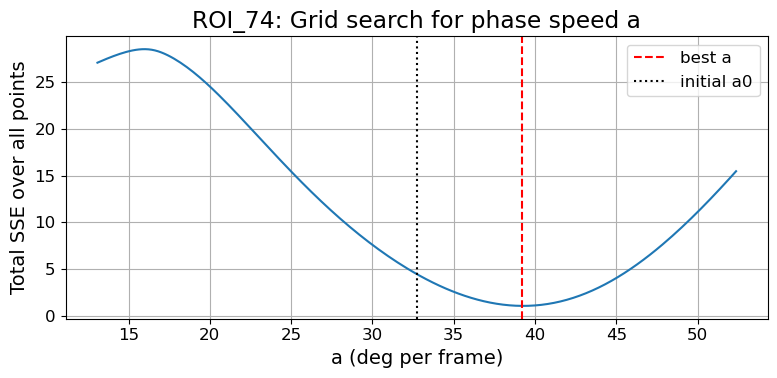


[ROI_74] Per-point best phases:
  pt1: b = 102.0 deg, SSE=0.2717
  pt2: b = 67.5 deg, SSE=0.1450
  pt3: b = 35.5 deg, SSE=0.1409
  pt4: b = 1.5 deg, SSE=0.2043
  pt5: b = 322.5 deg, SSE=0.1850
  pt6: b = 283.5 deg, SSE=0.0822
  pt7: b = 253.0 deg, SSE=0.0469


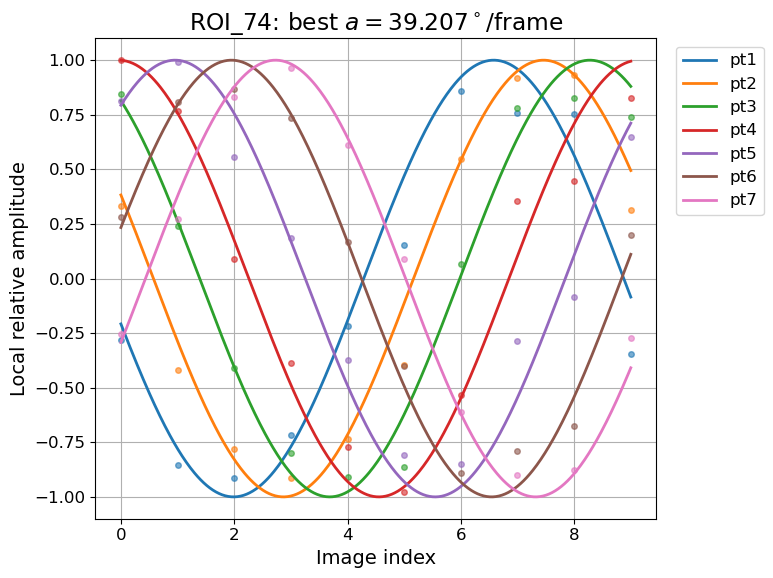


[ROI_74] Automatic direction = 1
[ROI_74] Phase slope across points = -35.29 deg/point
[ROI_74] Phase shift per frame = 39.207 deg/frame


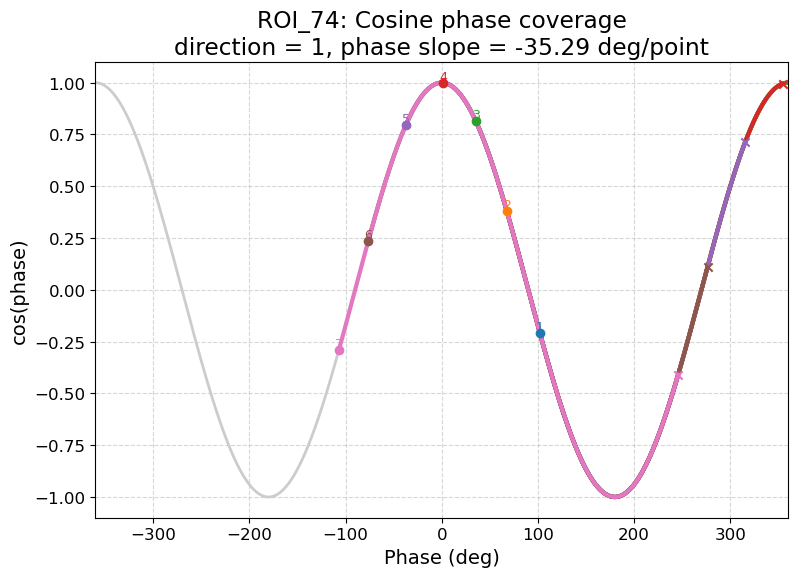


[ROI_74] Overall phase speed:
  avg wavelength = 12.60 ± 2.14 km
  avg angle = 167.88 ± 5.52 deg
  best a = 39.21 deg/frame
  direction = 1
  phase speed = 41.58 ± 7.05 m/s

[ROI_74] Running phase speed:
WINDOW=4, STEP=1, total windows=7

First window only plots
Rows 0..3, frames 0..3
Best a = 37.83 deg/frame
Avg λ = 12.56 ± 2.11 km
Avg angle = 167.91 ± 5.51 deg
Direction = 1
Phase slope = -36.02 deg/point
Signed phase speed = 40.01 ± 6.71 m/s


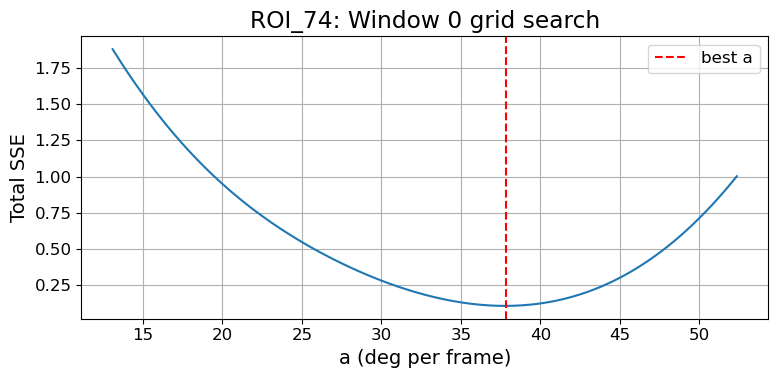

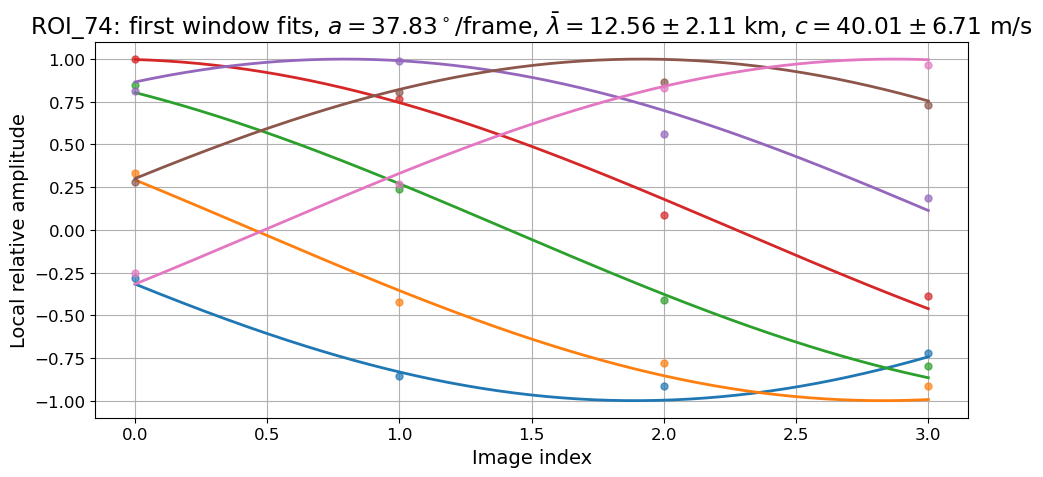


[ROI_74] Running-fit summary table:
 win  row_start  row_end a_deg/frame lambda_km lambda_err angle_deg angle_err  dir c_m/s c_err
   0          0        3       37.83     12.56       2.11    167.91      5.51    1 40.01  6.71
   1          1        4       36.46     12.58       2.16    168.00      5.51    1 38.61  6.63
   2          2        5       30.96     12.65       2.16    167.98      5.52    1 32.98  5.64
   3          3        6       39.21     12.62       2.17    167.97      5.52    1 41.64  7.18
   4          4        7       46.47     12.59       2.19    167.92      5.51    1 49.26  8.57
   5          5        8       40.19     12.66       2.12    167.77      5.52    1 42.83  7.17
   6          6        9       40.58     12.56       2.14    167.77      5.55    1 42.89  7.31


In [6]:
# %%
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load ROI CSVs from the same folder used by the batch pipeline
#
# Expected CSV format:
#   image_index,
#   wavelength_km,
#   wavelength_error_km,
#   angle_deg,
#   angle_error_deg,
#   pt1, pt2, ..., ptN
#
# This version:
#   - uses FOLDER instead of TIFF_DIR
#   - processes ALL ROI folders automatically
#   - keeps the same phase-fitting pipeline
#   - uses automatic direction
#   - removes manual phase shifting
#   - incorporates wavelength and angle from the CSV
#   - incorporates wavelength and angle standard deviations from the CSV
#   - calculates phase speed:
#
#       c = lambda * f
#
#       where:
#           f = (a / 360) / DT_FRAME_S
#           a = fitted phase shift in deg/frame
#           DT_FRAME_S = 33 s
#
#   - overall phase speed uses the mean wavelength
#   - overall wavelength error combines frame-to-frame spread and
#     wavelength_error_km from the CSV
#   - running-window phase speed uses window-mean wavelength
#   - running-window wavelength error combines the window spread and
#     wavelength_error_km from the CSV
#
# Notes:
#   - angle_deg and angle_error_deg are read, summarized, and included in
#     the running-fit table.
#   - angle is not directly used in c = lambda * f, but it is useful for
#     checking propagation direction/orientation of the selected wave.
# ------------------------------------------------------------

# If FOLDER is not already defined in a previous cell, uncomment this:
# FOLDER = Path().resolve() / "BLO Data" / "01787"

OVERLAY_DIR = None

ONLY_ROIS: list[str] | None = None

DT_FRAME_S = 33.0  # seconds between frames

# Running window settings for local phase speed
WINDOW = 4
STEP = 1
SHOW_FIRST_WINDOW_PLOTS = True


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def combine_mean_and_measurement_error(values, errors):
    """
    Combine frame-to-frame spread and per-frame measurement error.

    Returns:
        mean_value
        combined_error

    combined_error = sqrt(std(values)^2 + mean(error^2))

    This is a practical estimate, not a full formal uncertainty propagation.
    """
    values = np.asarray(values, float)

    finite_v = values[np.isfinite(values)]

    if finite_v.size == 0:
        return np.nan, np.nan

    mean_value = float(np.nanmean(values))

    if finite_v.size > 1:
        spread = float(np.nanstd(values, ddof=1))
    else:
        spread = 0.0

    if errors is None:
        meas = 0.0
    else:
        errors = np.asarray(errors, float)
        finite_e = errors[np.isfinite(errors)]

        if finite_e.size > 0:
            meas = float(np.sqrt(np.nanmean(finite_e**2)))
        else:
            meas = 0.0

    combined_error = float(np.sqrt(spread**2 + meas**2))

    return mean_value, combined_error


def load_roi_csv(csv_path: Path):
    print("\n" + "=" * 80)
    print("Loading CSV from:", csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        header = f.readline().strip().split(",")

    header_lc = [h.strip().lower() for h in header]

    def _find_col(name: str, required: bool = True):
        name_lc = name.lower()

        if name_lc not in header_lc:
            if required:
                raise ValueError(f"Column '{name}' not found in CSV header: {header}")
            return None

        return header_lc.index(name_lc)

    col_t = _find_col("image_index", required=True)

    col_lam = _find_col("wavelength_km", required=False)
    col_lam_err = _find_col("wavelength_error_km", required=False)

    col_angle = _find_col("angle_deg", required=False)
    col_angle_err = _find_col("angle_error_deg", required=False)

    metadata_cols = {
        c for c in [col_t, col_lam, col_lam_err, col_angle, col_angle_err]
        if c is not None
    }

    pt_cols = [
        i for i, h in enumerate(header_lc)
        if h.startswith("pt")
    ]

    if not pt_cols:
        pt_cols = [
            i for i in range(len(header_lc))
            if i not in metadata_cols
        ]

    if not pt_cols:
        raise ValueError(f"No point columns found in CSV header: {header}")

    pt_names = [header[i].strip() for i in pt_cols]

    data = np.genfromtxt(csv_path, delimiter=",", skip_header=1)

    if data.ndim == 1:
        data = data[None, :]

    t = data[:, col_t].astype(float)

    wavelength_km = data[:, col_lam].astype(float) if col_lam is not None else None
    wavelength_error_km = data[:, col_lam_err].astype(float) if col_lam_err is not None else None

    angle_deg = data[:, col_angle].astype(float) if col_angle is not None else None
    angle_error_deg = data[:, col_angle_err].astype(float) if col_angle_err is not None else None

    Y = data[:, pt_cols].astype(float)

    return (
        t,
        wavelength_km,
        wavelength_error_km,
        angle_deg,
        angle_error_deg,
        Y,
        pt_names,
    )


def fit_phase_grid_search(t, Y, pt_names, roi_name):
    n_frames, n_pts = Y.shape

    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors = [base_colors[j % len(base_colors)] for j in range(n_pts)]

    a0_deg = 360 / 11
    f_min, f_max = 0.4, 1.6
    n_trial = 201
    n_b = 720

    a_trial_deg = a0_deg * np.linspace(f_min, f_max, n_trial)
    a_trial = np.deg2rad(a_trial_deg)
    b_grid = np.linspace(0.0, 2.0 * np.pi, n_b, endpoint=False)

    errors = np.zeros(n_trial)

    for k, a_k in enumerate(a_trial):
        base_phase = a_k * t
        phase_mat = base_phase[:, None] + b_grid[None, :]
        cos_mat = np.cos(phase_mat)

        sse_total = 0.0

        for j in range(n_pts):
            y = Y[:, j][:, None]
            sse_b = np.sum((y - cos_mat) ** 2, axis=0)
            sse_total += np.min(sse_b)

        errors[k] = sse_total

    best_idx = int(np.argmin(errors))
    best_a = a_trial[best_idx]
    best_a_deg = float(a_trial_deg[best_idx])

    print(f"\n[{roi_name}] Best a = {best_a_deg:.3f} deg/frame")
    print(f"[{roi_name}] SSE_min = {errors[best_idx]:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(a_trial_deg, errors, "-")
    plt.axvline(best_a_deg, color="r", linestyle="--", label="best a")
    plt.axvline(a0_deg, color="k", linestyle=":", label="initial a0")
    plt.xlabel("a (deg per frame)")
    plt.ylabel("Total SSE over all points")
    plt.title(f"{roi_name}: Grid search for phase speed a")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    b_best = np.zeros(n_pts)
    sse_per_point = np.zeros(n_pts)

    base_phase_best = best_a * t
    phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
    cos_mat_best = np.cos(phase_mat_best)

    print(f"\n[{roi_name}] Per-point best phases:")

    for j in range(n_pts):
        y = Y[:, j][:, None]
        sse_b = np.sum((y - cos_mat_best) ** 2, axis=0)
        k_b = int(np.argmin(sse_b))

        b_best[j] = b_grid[k_b]
        sse_per_point[j] = sse_b[k_b]

        print(
            f"  {pt_names[j]}: b = {np.degrees(b_best[j]):.1f} deg, "
            f"SSE={sse_per_point[j]:.4f}"
        )

    t_fine = np.linspace(t.min(), t.max(), 500)

    plt.figure(figsize=(10, 6))

    for j in range(n_pts):
        col = colors[j]

        plt.plot(t, Y[:, j], "o", ms=4, alpha=0.6, color=col)
        plt.plot(
            t_fine,
            np.cos(best_a * t_fine + b_best[j]),
            "-",
            lw=2,
            color=col,
            label=pt_names[j],
        )

    plt.xlabel("Image index")
    plt.ylabel("Local relative amplitude")
    plt.title(rf"{roi_name}: best $a = {best_a_deg:.3f}^\circ$/frame")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()

    return best_a_deg, b_best, colors, n_pts, t, a_trial_deg, a_trial, b_grid


def estimate_direction_from_phase(b_best):
    b_unwrapped = np.unwrap(b_best)
    x_pts = np.arange(len(b_unwrapped))

    slope_rad = np.polyfit(x_pts, b_unwrapped, 1)[0]
    slope_deg = np.degrees(slope_rad)

    direction = -1 if slope_rad > 0 else 1

    return direction, slope_deg, b_unwrapped


def calculate_overall_phase_speed(
    best_a_deg,
    wavelength_km,
    wavelength_error_km=None,
    direction=1,
):
    if wavelength_km is None:
        return np.nan, np.nan, np.nan

    avg_wavelength_km, avg_wavelength_error_km = combine_mean_and_measurement_error(
        wavelength_km,
        wavelength_error_km,
    )

    speed_mps = 1000.0 * avg_wavelength_km * (best_a_deg / 360.0) / DT_FRAME_S

    speed_error_mps = (
        1000.0 * avg_wavelength_error_km * (best_a_deg / 360.0) / DT_FRAME_S
        if np.isfinite(avg_wavelength_error_km)
        else np.nan
    )

    speed_mps_signed = direction * speed_mps

    return avg_wavelength_km, avg_wavelength_error_km, speed_mps_signed, speed_error_mps


def make_single_cosine_summary_plot(roi_name, best_a_deg, b_best, colors, n_pts, t):
    direction, phase_slope_deg, b_unwrapped = estimate_direction_from_phase(b_best)

    phase_shift_per_frame_deg = direction * best_a_deg
    total_phase_span_deg = phase_shift_per_frame_deg * (len(t) - 1)

    print(f"\n[{roi_name}] Automatic direction = {direction}")
    print(f"[{roi_name}] Phase slope across points = {phase_slope_deg:.2f} deg/point")
    print(f"[{roi_name}] Phase shift per frame = {phase_shift_per_frame_deg:.3f} deg/frame")

    phi_deg = np.linspace(-360, 360, 2000)
    cos_phi = np.cos(np.radians(phi_deg))

    start_deg = np.degrees(b_unwrapped)

    center_phase = np.nanmean(start_deg)
    start_deg = start_deg - 360 * np.round(center_phase / 360)

    end_deg = start_deg + total_phase_span_deg

    plt.figure(figsize=(10, 6))
    plt.plot(phi_deg, cos_phi, color="0.8", lw=2, label="cosine")

    for j in range(n_pts):
        c = colors[j]
        s0 = start_deg[j]
        s1 = end_deg[j]

        lo, hi = sorted((s0, s1))
        mask = (phi_deg >= lo) & (phi_deg <= hi)

        if np.any(mask):
            plt.plot(phi_deg[mask], cos_phi[mask], lw=3, color=c)

        y0 = np.cos(np.radians(s0))
        y1 = np.cos(np.radians(s1))

        if -360 <= s0 <= 360:
            plt.scatter([s0], [y0], color=c, zorder=4)
            plt.text(s0, y0, f"{j + 1}", fontsize=9, ha="center", va="bottom", color=c)

        if -360 <= s1 <= 360:
            plt.scatter([s1], [y1], color=c, zorder=4, marker="x")

    plt.xlabel("Phase (deg)")
    plt.ylabel("cos(phase)")
    plt.title(
        f"{roi_name}: Cosine phase coverage\n"
        f"direction = {direction}, phase slope = {phase_slope_deg:.2f} deg/point"
    )
    plt.xlim(-360, 360)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    return direction, phase_slope_deg


def running_phase_speed(
    roi_name,
    t,
    Y,
    wavelength_km,
    wavelength_error_km,
    angle_deg,
    angle_error_deg,
    colors,
    a_trial_deg,
    a_trial,
    b_grid,
):
    if wavelength_km is None:
        print(f"[{roi_name}] No wavelength_km column. Skipping running phase speed.")
        return None

    n_frames, n_pts = Y.shape

    if n_frames < WINDOW:
        print(f"[{roi_name}] Not enough frames for WINDOW={WINDOW}. Skipping running fit.")
        return None

    results = []
    n_windows = 1 + (n_frames - WINDOW) // STEP

    print(f"\n[{roi_name}] Running phase speed:")
    print(f"WINDOW={WINDOW}, STEP={STEP}, total windows={n_windows}")

    for w_idx, start in enumerate(range(0, n_frames - WINDOW + 1, STEP)):
        end = start + WINDOW

        t_w = t[start:end]
        Y_w = Y[start:end, :]

        lam_w_km = wavelength_km[start:end]
        lam_err_w_km = (
            wavelength_error_km[start:end]
            if wavelength_error_km is not None
            else None
        )

        angle_w_deg = (
            angle_deg[start:end]
            if angle_deg is not None
            else None
        )

        angle_err_w_deg = (
            angle_error_deg[start:end]
            if angle_error_deg is not None
            else None
        )

        lam_avg_km, lam_avg_err_km = combine_mean_and_measurement_error(
            lam_w_km,
            lam_err_w_km,
        )

        if angle_w_deg is not None:
            angle_avg_deg, angle_avg_err_deg = combine_mean_and_measurement_error(
                angle_w_deg,
                angle_err_w_deg,
            )
        else:
            angle_avg_deg, angle_avg_err_deg = np.nan, np.nan

        errors_w = np.zeros(len(a_trial), dtype=float)

        for k, a_k in enumerate(a_trial):
            base_phase = a_k * t_w
            phase_mat = base_phase[:, None] + b_grid[None, :]
            cos_mat = np.cos(phase_mat)

            sse_total = 0.0

            for j in range(n_pts):
                yj = Y_w[:, j][:, None]
                sse_b = np.sum((yj - cos_mat) ** 2, axis=0)
                sse_total += np.min(sse_b)

            errors_w[k] = sse_total

        best_k = int(np.argmin(errors_w))
        best_a_deg_w = float(a_trial_deg[best_k])
        best_a_w = float(a_trial[best_k])
        sse_min_w = float(errors_w[best_k])

        base_phase_best = best_a_w * t_w
        phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
        cos_mat_best = np.cos(phase_mat_best)

        b_best_w = np.zeros(n_pts)

        for j in range(n_pts):
            yj = Y_w[:, j][:, None]
            sse_b = np.sum((yj - cos_mat_best) ** 2, axis=0)
            b_best_w[j] = b_grid[int(np.argmin(sse_b))]

        direction_w, phase_slope_deg_w, _ = estimate_direction_from_phase(b_best_w)

        if np.isfinite(lam_avg_km):
            phase_speed_mps = 1000.0 * lam_avg_km * (best_a_deg_w / 360.0) / DT_FRAME_S
            phase_speed_mps_signed = direction_w * phase_speed_mps
        else:
            phase_speed_mps_signed = np.nan

        if np.isfinite(lam_avg_err_km):
            phase_speed_err_mps = (
                1000.0 * lam_avg_err_km * (best_a_deg_w / 360.0) / DT_FRAME_S
            )
        else:
            phase_speed_err_mps = np.nan

        results.append({
            "window_index": w_idx,
            "start_row": int(start),
            "end_row": int(end - 1),
            "start_frame": float(t_w[0]),
            "end_frame": float(t_w[-1]),
            "best_a_deg_per_frame": best_a_deg_w,
            "avg_wavelength_km": lam_avg_km,
            "avg_wavelength_error_km": lam_avg_err_km,
            "avg_angle_deg": angle_avg_deg,
            "avg_angle_error_deg": angle_avg_err_deg,
            "direction": int(direction_w),
            "phase_slope_deg_per_point": float(phase_slope_deg_w),
            "phase_speed_m_per_s": float(phase_speed_mps_signed),
            "phase_speed_error_m_per_s": float(phase_speed_err_mps),
            "SSE_min": sse_min_w,
        })

        if SHOW_FIRST_WINDOW_PLOTS and w_idx == 0:
            print("\nFirst window only plots")
            print(f"Rows {start}..{end - 1}, frames {t_w[0]:.0f}..{t_w[-1]:.0f}")
            print(f"Best a = {best_a_deg_w:.2f} deg/frame")
            print(f"Avg λ = {lam_avg_km:.2f} ± {lam_avg_err_km:.2f} km")
            print(f"Avg angle = {angle_avg_deg:.2f} ± {angle_avg_err_deg:.2f} deg")
            print(f"Direction = {direction_w}")
            print(f"Phase slope = {phase_slope_deg_w:.2f} deg/point")
            print(f"Signed phase speed = {phase_speed_mps_signed:.2f} ± {phase_speed_err_mps:.2f} m/s")

            plt.figure(figsize=(8, 4))
            plt.plot(a_trial_deg, errors_w, "-")
            plt.axvline(best_a_deg_w, color="r", linestyle="--", label="best a")
            plt.xlabel("a (deg per frame)")
            plt.ylabel("Total SSE")
            plt.title(f"{roi_name}: Window 0 grid search")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

            t_fine = np.linspace(t_w.min(), t_w.max(), 200)

            plt.figure(figsize=(10, 5))

            for j in range(n_pts):
                col = colors[j]

                plt.plot(t_w, Y_w[:, j], "o", ms=5, alpha=0.7, color=col)
                plt.plot(
                    t_fine,
                    np.cos(best_a_w * t_fine + b_best_w[j]),
                    "-",
                    lw=2,
                    color=col,
                )

            plt.xlabel("Image index")
            plt.ylabel("Local relative amplitude")
            plt.title(
                rf"{roi_name}: first window fits, "
                rf"$a = {best_a_deg_w:.2f}^\circ$/frame, "
                rf"$\bar{{\lambda}} = {lam_avg_km:.2f}\pm{lam_avg_err_km:.2f}$ km, "
                rf"$c = {phase_speed_mps_signed:.2f}\pm{phase_speed_err_mps:.2f}$ m/s"
            )
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    try:
        import pandas as pd

        df = pd.DataFrame(results)

        df_show = df[[
            "window_index",
            "start_row",
            "end_row",
            "best_a_deg_per_frame",
            "avg_wavelength_km",
            "avg_wavelength_error_km",
            "avg_angle_deg",
            "avg_angle_error_deg",
            "direction",
            "phase_speed_m_per_s",
            "phase_speed_error_m_per_s",
        ]].copy()

        df_show.columns = [
            "win",
            "row_start",
            "row_end",
            "a_deg/frame",
            "lambda_km",
            "lambda_err",
            "angle_deg",
            "angle_err",
            "dir",
            "c_m/s",
            "c_err",
        ]

        for c in [
            "a_deg/frame",
            "lambda_km",
            "lambda_err",
            "angle_deg",
            "angle_err",
            "c_m/s",
            "c_err",
        ]:
            df_show[c] = df_show[c].map(lambda x: f"{x:.2f}" if np.isfinite(x) else "nan")

        print(f"\n[{roi_name}] Running-fit summary table:")
        print(df_show.to_string(index=False))

    except Exception:
        print(f"\n[{roi_name}] Running-fit summary table:")

        for r in results:
            print(r)

    return results


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
if "FOLDER" not in globals():
    raise NameError(
        'FOLDER is not defined. Define it first, e.g.\n'
        'FOLDER = Path().resolve() / "BLO Data" / "01787"'
    )

frame_dir = Path(FOLDER)

if OVERLAY_DIR is not None:
    overlay_base = Path(OVERLAY_DIR)
else:
    overlay_base = frame_dir / "overlays_crests_phase"

roi_csvs = sorted(overlay_base.glob("*/crest_relative_amplitude_evolution.csv"))

if ONLY_ROIS is not None:
    only_set = set(ONLY_ROIS)
    roi_csvs = [p for p in roi_csvs if p.parent.name in only_set]

if not roi_csvs:
    raise FileNotFoundError(
        f"No ROI CSVs found in:\n  {overlay_base}\n"
        "Make sure the batch cell finished and created ROI subfolders."
    )

print("Overlay base:", overlay_base)
print("Found ROI CSVs:")

for p in roi_csvs:
    print(" ", p.parent.name)

for csv_path in roi_csvs:
    roi_name = csv_path.parent.name

    (
        t,
        wavelength_km,
        wavelength_error_km,
        angle_deg,
        angle_error_deg,
        Y,
        pt_names,
    ) = load_roi_csv(csv_path)

    if wavelength_km is not None:
        print(
            f"[{roi_name}] Wavelength stats (km): "
            f"min={np.nanmin(wavelength_km):.2f}, "
            f"median={np.nanmedian(wavelength_km):.2f}, "
            f"max={np.nanmax(wavelength_km):.2f}"
        )

    if wavelength_error_km is not None:
        print(
            f"[{roi_name}] Wavelength error stats (km): "
            f"median={np.nanmedian(wavelength_error_km):.2f}, "
            f"max={np.nanmax(wavelength_error_km):.2f}"
        )

    if angle_deg is not None:
        print(
            f"[{roi_name}] Angle stats (deg): "
            f"min={np.nanmin(angle_deg):.2f}, "
            f"median={np.nanmedian(angle_deg):.2f}, "
            f"max={np.nanmax(angle_deg):.2f}"
        )

    if angle_error_deg is not None:
        print(
            f"[{roi_name}] Angle error stats (deg): "
            f"median={np.nanmedian(angle_error_deg):.2f}, "
            f"max={np.nanmax(angle_error_deg):.2f}"
        )

    best_a_deg, b_best, colors, n_pts, t, a_trial_deg, a_trial, b_grid = fit_phase_grid_search(
        t=t,
        Y=Y,
        pt_names=pt_names,
        roi_name=roi_name,
    )

    direction, phase_slope_deg = make_single_cosine_summary_plot(
        roi_name=roi_name,
        best_a_deg=best_a_deg,
        b_best=b_best,
        colors=colors,
        n_pts=n_pts,
        t=t,
    )

    (
        avg_wavelength_km,
        avg_wavelength_error_km,
        overall_phase_speed_mps,
        overall_phase_speed_error_mps,
    ) = calculate_overall_phase_speed(
        best_a_deg=best_a_deg,
        wavelength_km=wavelength_km,
        wavelength_error_km=wavelength_error_km,
        direction=direction,
    )

    if angle_deg is not None:
        avg_angle_deg, avg_angle_error_deg = combine_mean_and_measurement_error(
            angle_deg,
            angle_error_deg,
        )
    else:
        avg_angle_deg, avg_angle_error_deg = np.nan, np.nan

    print(f"\n[{roi_name}] Overall phase speed:")
    print(f"  avg wavelength = {avg_wavelength_km:.2f} ± {avg_wavelength_error_km:.2f} km")
    print(f"  avg angle = {avg_angle_deg:.2f} ± {avg_angle_error_deg:.2f} deg")
    print(f"  best a = {best_a_deg:.2f} deg/frame")
    print(f"  direction = {direction}")
    print(f"  phase speed = {overall_phase_speed_mps:.2f} ± {overall_phase_speed_error_mps:.2f} m/s")

    running_phase_speed(
        roi_name=roi_name,
        t=t,
        Y=Y,
        wavelength_km=wavelength_km,
        wavelength_error_km=wavelength_error_km,
        angle_deg=angle_deg,
        angle_error_deg=angle_error_deg,
        colors=colors,
        a_trial_deg=a_trial_deg,
        a_trial=a_trial,
        b_grid=b_grid,
    )